

**1.   Import Library**




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Library berhasil diimport!")

✅ Library berhasil diimport!


Pada cell ini kita mengimpor semua library Python yang akan digunakan sepanjang proses analisis.
Pandas digunakan untuk membaca dan memanipulasi data dalam format tabel, numpy untuk operasi
matematis, matplotlib sebagai library dasar pembuatan grafik, dan seaborn untuk visualisasi
statistik yang lebih informatif seperti heatmap dan histogram. Semua library ini perlu diimpor
di awal karena akan digunakan berulang kali di cell-cell berikutnya.




**2.   Memuat Dataset**



In [ ]:
from google.colab import files

# Muncul tombol upload → pilih file data_ecommerce_klasterisasi.csv
uploaded = files.upload()

Saving data_ecommerce_klasterisasi.csv to data_ecommerce_klasterisasi.csv


In [ ]:
df = pd.read_csv('data_ecommerce_klasterisasi.csv', sep=';')

print("✅ Dataset berhasil dimuat!")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
df.head()

✅ Dataset berhasil dimuat!
Jumlah baris: 200
Jumlah kolom: 11


,ID Pelanggan,Jenis Kelamin,Usia,Pendapatan Tahunan (juta Rp),Skor Belanja (1-100),Transaksi per Bulan,Rata-rata Nilai Transaksi (juta Rp),Jumlah Kategori Produk Dibeli,Frekuensi Penggunaan Promo,Rata-rata Rating Diberikan,Metode Pembayaran Favorit
0,1,Laki-laki,19,15,39,2,0.8,1,5,3.9,Dompet Digital
1,2,Laki-laki,21,15,81,4,0.9,1,3,3.6,Dompet Digital
2,3,Perempuan,20,16,6,1,1.2,1,5,3.1,Bayar di Tempat
3,4,Perempuan,23,16,77,5,1.2,2,6,3.5,Bayar di Tempat
4,5,Perempuan,31,17,40,2,0.5,1,5,3.2,Kartu Kredit


Karena kita bekerja di Google Colab yang berjalan di cloud, file CSV tidak bisa diakses langsung
dari komputer lokal. Kita mengunggahnya terlebih dahulu menggunakan files.upload(), lalu membacanya
dengan pd.read_csv() yang mengubah isi file menjadi sebuah DataFrame — struktur data seperti tabel
Excel yang bisa diolah dengan Python. df.head() digunakan untuk memverifikasi bahwa data berhasil
dimuat dengan menampilkan 5 baris pertama.



**3.   Eksplorasi Data**




***Struktur data:***

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ID Pelanggan                         200 non-null    int64  
 1   Jenis Kelamin                        200 non-null    object 
 2   Usia                                 200 non-null    int64  
 3   Pendapatan Tahunan (juta Rp)         200 non-null    int64  
 4   Skor Belanja (1-100)                 200 non-null    int64  
 5   Transaksi per Bulan                  200 non-null    int64  
 6   Rata-rata Nilai Transaksi (juta Rp)  200 non-null    float64
 7   Jumlah Kategori Produk Dibeli        200 non-null    int64  
 8   Frekuensi Penggunaan Promo           200 non-null    int64  
 9   Rata-rata Rating Diberikan           200 non-null    float64
 10  Metode Pembayaran Favorit            200 non-null    object 
dtypes: float64(2), int64(7), object(

***Statistik deskriptif:***

In [ ]:
df.describe(include='all')

,ID Pelanggan,Jenis Kelamin,Usia,Pendapatan Tahunan (juta Rp),Skor Belanja (1-100),Transaksi per Bulan,Rata-rata Nilai Transaksi (juta Rp),Jumlah Kategori Produk Dibeli,Frekuensi Penggunaan Promo,Rata-rata Rating Diberikan,Metode Pembayaran Favorit
count,200.000000,200,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,Perempuan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dompet Digital
freq,NaN,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57
mean,100.500000,NaN,38.850000,60.560000,50.200000,2.620000,2.478500,1.235000,2.075000,3.566500,NaN
std,57.879185,NaN,13.969007,26.264721,25.823522,1.423281,1.136285,0.490897,1.610074,0.534374,NaN
min,1.000000,NaN,18.000000,15.000000,1.000000,1.000000,0.500000,1.000000,0.000000,2.300000,NaN
25%,50.750000,NaN,28.750000,41.500000,34.750000,1.000000,1.500000,1.000000,1.000000,3.200000,NaN
50%,100.500000,NaN,36.000000,61.500000,50.000000,2.000000,2.500000,1.000000,2.000000,3.600000,NaN
75%,150.250000,NaN,49.000000,78.000000,73.000000,4.000000,3.200000,1.000000,3.000000,3.925000,NaN


***Cek missing values:***

In [ ]:
print("=== Missing Values ===")
print(df.isnull().sum())

=== Missing Values ===
ID Pelanggan                           0
Jenis Kelamin                          0
Usia                                   0
Pendapatan Tahunan (juta Rp)           0
Skor Belanja (1-100)                   0
Transaksi per Bulan                    0
Rata-rata Nilai Transaksi (juta Rp)    0
Jumlah Kategori Produk Dibeli          0
Frekuensi Penggunaan Promo             0
Rata-rata Rating Diberikan             0
Metode Pembayaran Favorit              0
dtype: int64


***Cek data duplikat:***

In [ ]:
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 0


***Distribusi Jenis Kelamin:***

In [ ]:
df = pd.read_csv('data_ecommerce_klasterisasi.csv', sep=',')

***Distribusi Metode Pembayaran:***

In [ ]:
df = pd.read_csv('data_ecommerce_klasterisasi.csv', sep=';')
print(df['Metode Pembayaran Favorit'].value_counts())

Metode Pembayaran Favorit
Dompet Digital     57
Bayar di Tempat    57
Kartu Kredit       54
Transfer Bank      32
Name: count, dtype: int64


EDA atau Exploratory Data Analysis adalah proses mengenal dataset sebelum diolah lebih lanjut.
df.info() menampilkan struktur data seperti tipe kolom dan jumlah nilai yang tidak kosong.
df.describe() menampilkan statistik deskriptif seperti nilai minimum, maksimum, dan rata-rata.
df.isnull().sum() mengecek apakah ada nilai kosong yang perlu ditangani, sedangkan
df.duplicated().sum() mengecek apakah ada baris yang identik. Kedua masalah ini jika dibiarkan
dapat merusak kualitas hasil clustering.



**4.   Visualisasi Eksplorasi Data**




***Distribusi kolom numerik:***

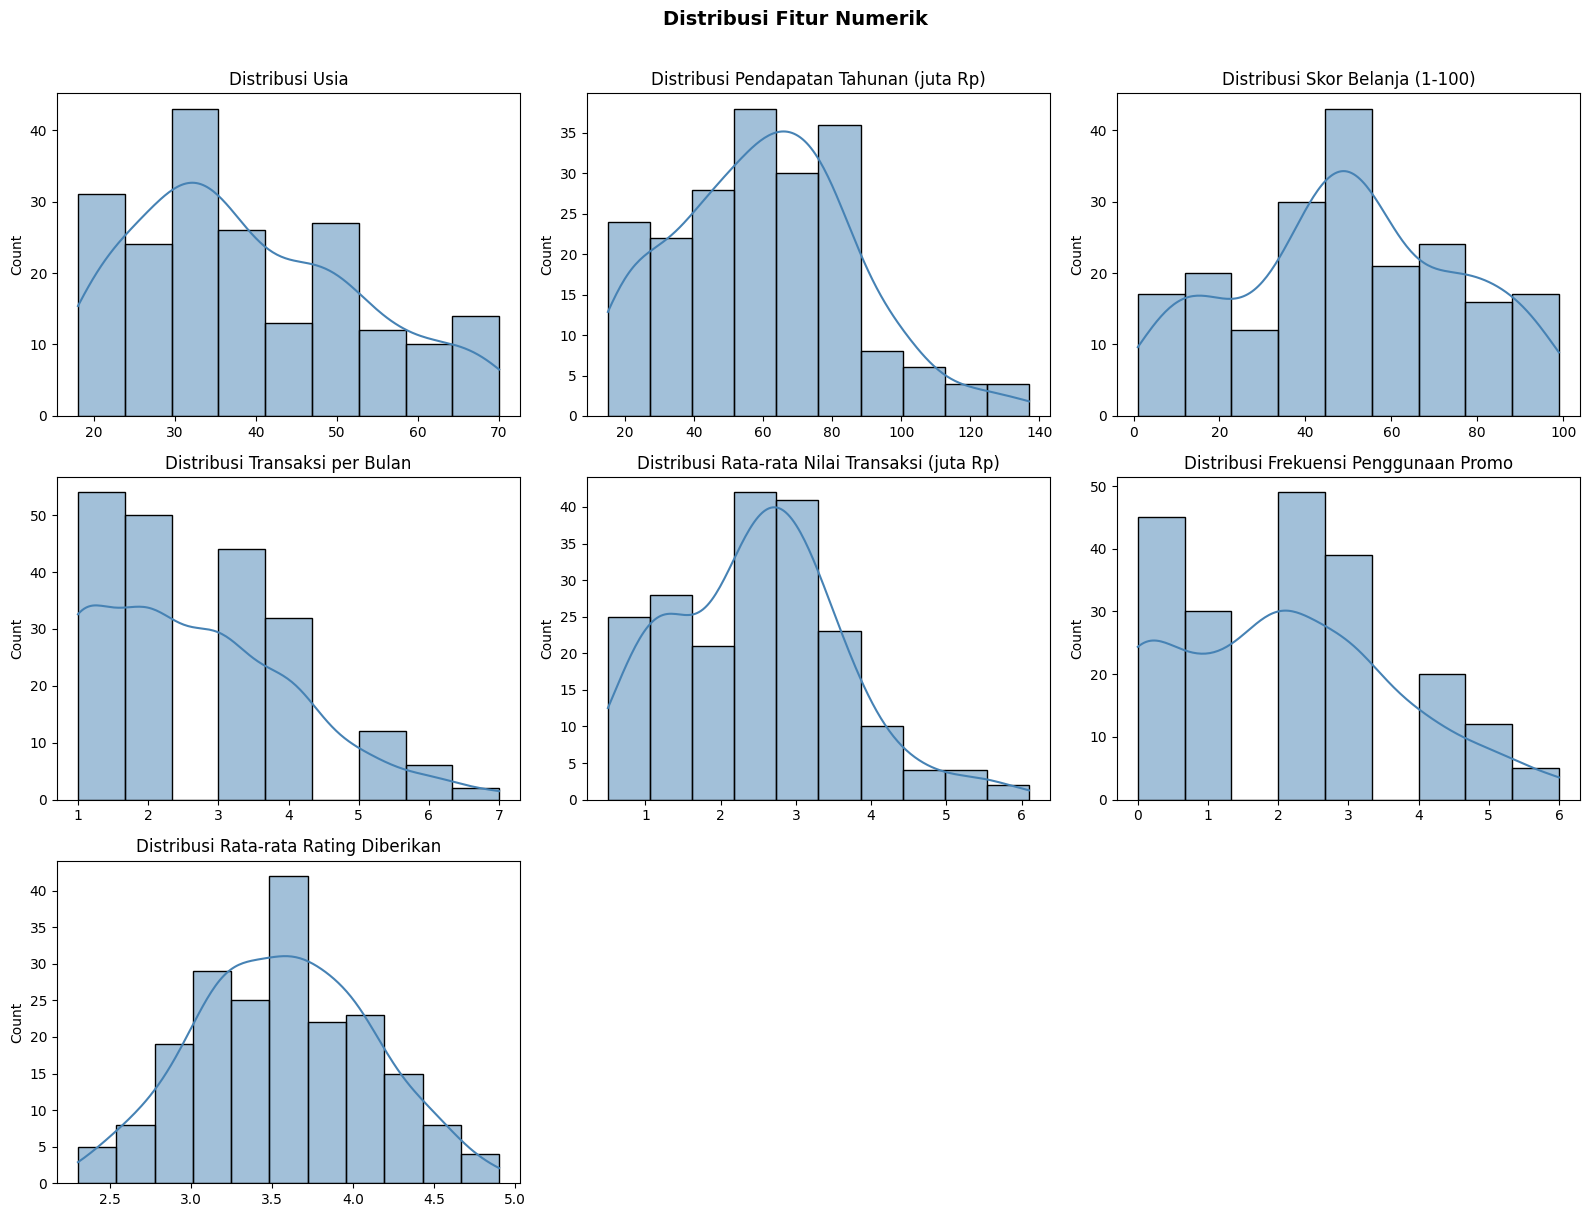

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

kolom_numerik = ['Usia', 'Pendapatan Tahunan (juta Rp)', 'Skor Belanja (1-100)',
                 'Transaksi per Bulan', 'Rata-rata Nilai Transaksi (juta Rp)',
                 'Frekuensi Penggunaan Promo', 'Rata-rata Rating Diberikan']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, kolom in enumerate(kolom_numerik):
    sns.histplot(df[kolom], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribusi {kolom}')
    axes[i].set_xlabel('')

# Sembunyikan subplot kosong
for j in range(len(kolom_numerik), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

***Distribusi kolom kategorikal:***

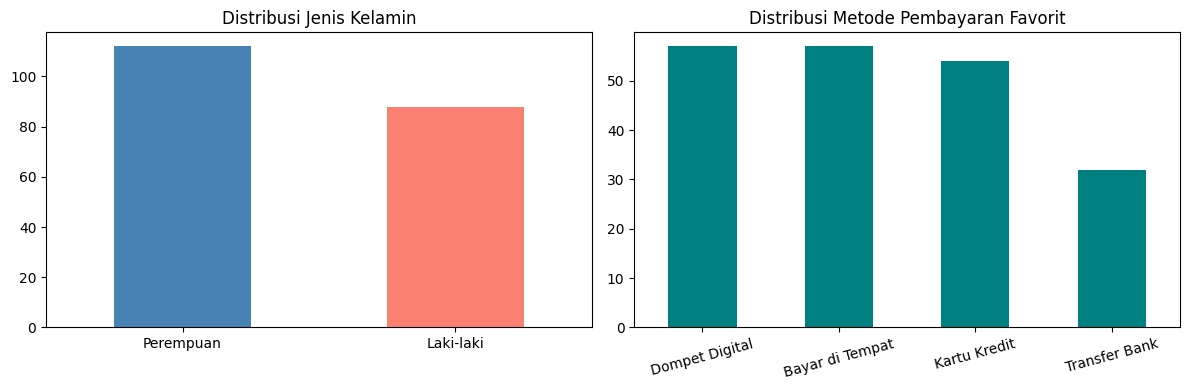

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Jenis Kelamin'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Distribusi Jenis Kelamin')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

df['Metode Pembayaran Favorit'].value_counts().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Distribusi Metode Pembayaran Favorit')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

***Heatmap korelasi:***

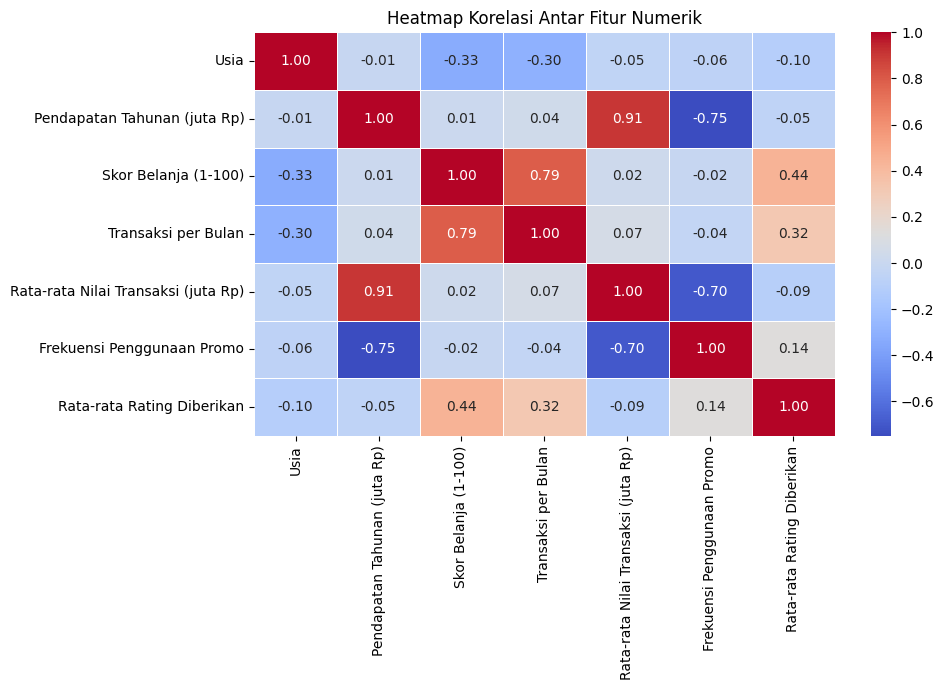

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[kolom_numerik].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.tight_layout()
plt.show()

***Scatter plot pendapatan vs skor belanja:***

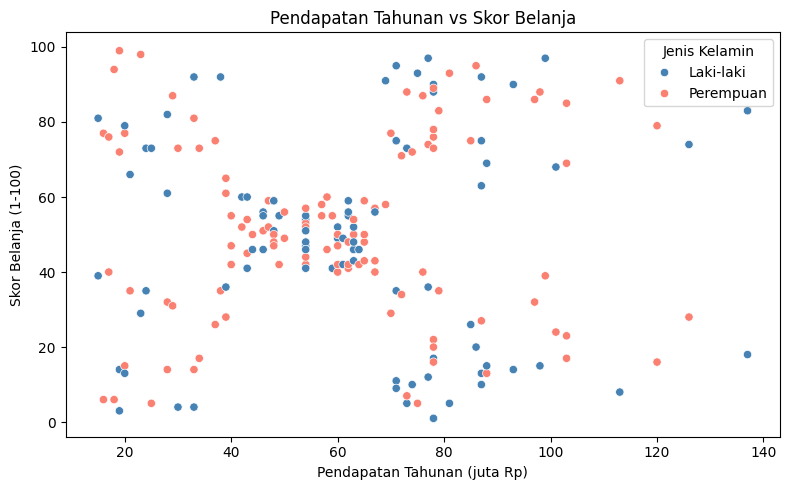

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Pendapatan Tahunan (juta Rp)', y='Skor Belanja (1-100)',
                hue='Jenis Kelamin', palette={'Laki-laki': 'steelblue', 'Perempuan': 'salmon'})
plt.title('Pendapatan Tahunan vs Skor Belanja')
plt.tight_layout()
plt.show()

Visualisasi membantu kita memahami pola dan distribusi data secara intuitif. Histogram dengan
kurva KDE menampilkan sebaran nilai setiap kolom numerik — dari sini kita bisa melihat apakah
data terdistribusi normal atau miring. Bar chart menampilkan proporsi nilai pada kolom kategorikal
seperti Jenis Kelamin dan Metode Pembayaran. Heatmap korelasi menunjukkan seberapa kuat hubungan
antara satu kolom dengan kolom lainnya. Scatter plot Pendapatan vs Skor Belanja digunakan untuk
melihat apakah sudah terlihat pola pengelompokan alami sebelum model dijalankan.



**5.   Cleaning & Preprocessing**




**Hapus kolom ID Pelanggan**

In [ ]:
df_clean = df.drop(columns=['ID Pelanggan'])
print("Kolom setelah drop ID Pelanggan:")
print(df_clean.columns.tolist())

Kolom setelah drop ID Pelanggan:
['Jenis Kelamin', 'Usia', 'Pendapatan Tahunan (juta Rp)', 'Skor Belanja (1-100)', 'Transaksi per Bulan', 'Rata-rata Nilai Transaksi (juta Rp)', 'Jumlah Kategori Produk Dibeli', 'Frekuensi Penggunaan Promo', 'Rata-rata Rating Diberikan', 'Metode Pembayaran Favorit']


***Encoding kolom kategorikal***

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encoding Jenis Kelamin
df_clean['Jenis Kelamin'] = le.fit_transform(df_clean['Jenis Kelamin'])
print("Jenis Kelamin:", dict(zip(le.classes_, le.transform(le.classes_))))

# Encoding Metode Pembayaran Favorit
df_clean['Metode Pembayaran Favorit'] = le.fit_transform(df_clean['Metode Pembayaran Favorit'])
print("Metode Pembayaran:", dict(zip(le.classes_, le.transform(le.classes_))))

df_clean.head()

Jenis Kelamin: {'Laki-laki': np.int64(0), 'Perempuan': np.int64(1)}
Metode Pembayaran: {'Bayar di Tempat': np.int64(0), 'Dompet Digital': np.int64(1), 'Kartu Kredit': np.int64(2), 'Transfer Bank': np.int64(3)}


,Jenis Kelamin,Usia,Pendapatan Tahunan (juta Rp),Skor Belanja (1-100),Transaksi per Bulan,Rata-rata Nilai Transaksi (juta Rp),Jumlah Kategori Produk Dibeli,Frekuensi Penggunaan Promo,Rata-rata Rating Diberikan,Metode Pembayaran Favorit
0,0,19,15,39,2,0.8,1,5,3.9,1
1,0,21,15,81,4,0.9,1,3,3.6,1
2,1,20,16,6,1,1.2,1,5,3.1,0
3,1,23,16,77,5,1.2,2,6,3.5,0
4,1,31,17,40,2,0.5,1,5,3.2,2


***Normalisasi semua kolom numerik:***

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

df_scaled = pd.DataFrame(X_scaled, columns=df_clean.columns)

print("✅ Normalisasi selesai!")
df_scaled.head()

✅ Normalisasi selesai!


,Jenis Kelamin,Usia,Pendapatan Tahunan (juta Rp),Skor Belanja (1-100),Transaksi per Bulan,Rata-rata Nilai Transaksi (juta Rp),Jumlah Kategori Produk Dibeli,Frekuensi Penggunaan Promo,Rata-rata Rating Diberikan,Metode Pembayaran Favorit
0,-1.128152,-1.424569,-1.738999,-0.434801,-0.436706,-1.480889,-0.479917,1.821246,0.625661,-0.290545
1,-1.128152,-1.281035,-1.738999,1.195704,0.972024,-1.392662,-0.479917,0.575950,0.062847,-0.290545
2,0.886405,-1.352802,-1.700830,-1.715913,-1.141071,-1.127981,-0.479917,1.821246,-0.875175,-1.243153
3,0.886405,-1.137502,-1.700830,1.040418,1.676389,-1.127981,1.562282,2.443894,-0.124757,-1.243153
4,0.886405,-0.563369,-1.662660,-0.395980,-0.436706,-1.745570,-0.479917,1.821246,-0.687570,0.662062


Preprocessing adalah proses mengubah data mentah menjadi format yang siap digunakan oleh
algoritma machine learning. Ada tiga langkah yang dilakukan.

Pertama, kolom ID Pelanggan dihapus karena hanya berisi angka urut yang tidak mencerminkan
perilaku pelanggan. Jika ikut dihitung, ID akan mengacaukan jarak antar data karena pelanggan
dengan nomor ID berjauhan akan dianggap berbeda meski perilakunya serupa.

Kedua, kolom kategorikal diubah menjadi angka menggunakan LabelEncoder, karena K-Means hanya
bisa memproses angka, bukan teks.

Ketiga, semua kolom dinormalisasi menggunakan StandardScaler agar memiliki skala yang setara.
Tanpa normalisasi, kolom dengan angka besar seperti Pendapatan akan mendominasi perhitungan
jarak dan menghasilkan klaster yang bias.



**6.  Simpan Dataset**


In [ ]:
# Simpan versi cleaned (sudah di-encode, belum discale)
df_clean.to_csv('data_cleaned.csv', index=False)

# Simpan versi scaled (siap untuk model)
df_scaled.to_csv('data_scaled.csv', index=False)

print("✅ Dataset berhasil disimpan!")

✅ Dataset berhasil disimpan!


In [ ]:
files.download('data_cleaned.csv')
files.download('data_scaled.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Upload dataset untuk digunakan pada pelatihan model**

In [ ]:
import pandas as pd

df_scaled = pd.read_csv('data_scaled.csv')
print("✅ Dataset scaled berhasil dimuat!")
df_scaled.head()


✅ Dataset scaled berhasil dimuat!


,Jenis Kelamin,Usia,Pendapatan Tahunan (juta Rp),Skor Belanja (1-100),Transaksi per Bulan,Rata-rata Nilai Transaksi (juta Rp),Jumlah Kategori Produk Dibeli,Frekuensi Penggunaan Promo,Rata-rata Rating Diberikan,Metode Pembayaran Favorit
0,-1.128152,-1.424569,-1.738999,-0.434801,-0.436706,-1.480889,-0.479917,1.821246,0.625661,-0.290545
1,-1.128152,-1.281035,-1.738999,1.195704,0.972024,-1.392662,-0.479917,0.575950,0.062847,-0.290545
2,0.886405,-1.352802,-1.700830,-1.715913,-1.141071,-1.127981,-0.479917,1.821246,-0.875175,-1.243153
3,0.886405,-1.137502,-1.700830,1.040418,1.676389,-1.127981,1.562282,2.443894,-0.124757,-1.243153
4,0.886405,-0.563369,-1.662660,-0.395980,-0.436706,-1.745570,-0.479917,1.821246,-0.687570,0.662062


Kita menyimpan dua versi dataset. data_cleaned.csv adalah versi yang sudah di-encode namun
belum dinormalisasi, berguna untuk analisis dan interpretasi karena angkanya masih dalam skala
aslinya. data_scaled.csv adalah versi yang sudah sepenuhnya diproses termasuk normalisasi, dan
inilah yang akan digunakan sebagai input model machine learning di tahap berikutnya.
files.download() digunakan untuk mengunduh file dari Colab ke komputer lokal.

**7.Install Library Tambahan**

In [ ]:
!pip install yellowbrick -q

print("✅ Yellowbrick berhasil diinstall!")

✅ Yellowbrick berhasil diinstall!


Kita menginstal library Yellowbrick yang belum tersedia secara default di Google Colab.
Yellowbrick dirancang khusus untuk memudahkan visualisasi proses dan hasil machine learning.
Kita akan menggunakannya untuk membuat grafik Elbow Method dan Silhouette Visualizer secara
otomatis. Tanda seru di depan perintah berarti kita menjalankan perintah sistem dari dalam notebook.

**8. Tentukan Jumlah Cluster Optimal (Elbow Method)**

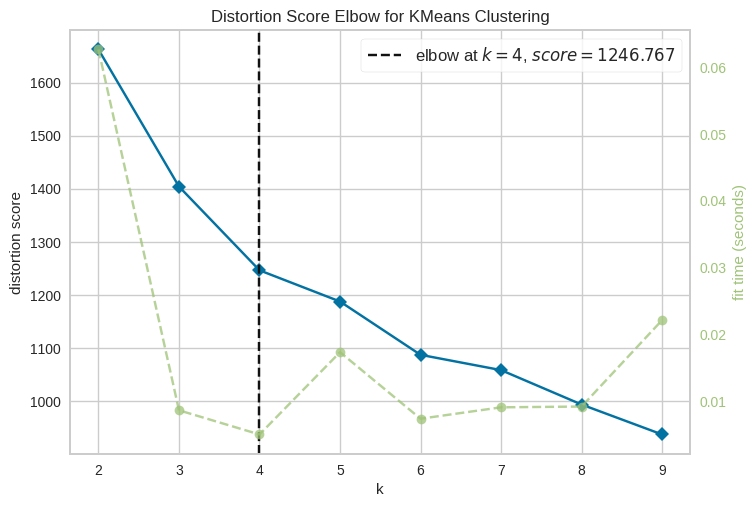


✅ Jumlah cluster optimal: 4


In [ ]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

model = KMeans(random_state=42)

visualizer = KElbowVisualizer(model, k=(2, 10))
visualizer.fit(df_scaled)
visualizer.show()

k_optimal = visualizer.elbow_value_
print(f"\n✅ Jumlah cluster optimal: {k_optimal}")

Elbow Method adalah teknik untuk menentukan jumlah cluster optimal. Cara kerjanya adalah
menjalankan K-Means untuk berbagai nilai K (dari 2 hingga 9), lalu mengukur nilai inertia
untuk setiap K. Inertia adalah total jarak kuadrat antara setiap data point dengan pusat
clusternya. Semakin banyak cluster, inertia semakin kecil — namun ada titik di mana
penurunannya mulai melambat dan membentuk sudut seperti siku. Titik siku itulah nilai K
yang optimal, dan Yellowbrick mendeteksinya secara otomatis pada grafik.

**9. Konfirmasi dengan Silhouette Score**

K=2 → Silhouette Score: 0.1540
K=3 → Silhouette Score: 0.1587
K=4 → Silhouette Score: 0.1685
K=5 → Silhouette Score: 0.1439
K=6 → Silhouette Score: 0.1575
K=7 → Silhouette Score: 0.1333
K=8 → Silhouette Score: 0.1396
K=9 → Silhouette Score: 0.1430


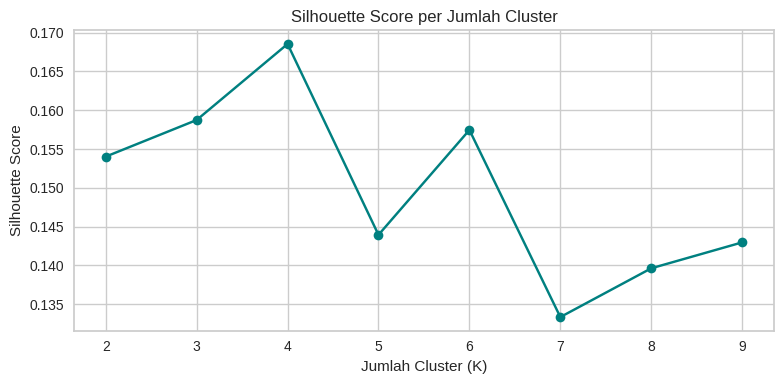


✅ K terbaik berdasarkan Silhouette Score: 4


In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k} → Silhouette Score: {score:.4f}")

# Visualisasi
plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, marker='o', color='teal')
plt.title('Silhouette Score per Jumlah Cluster')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()

k_terbaik = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\n✅ K terbaik berdasarkan Silhouette Score: {k_terbaik}")

Silhouette Score digunakan sebagai konfirmasi kedua setelah Elbow Method. Metrik ini mengukur
seberapa baik setiap data point berada di dalam clusternya sendiri dibandingkan cluster lain.
Nilainya berkisar -1 hingga 1, di mana nilai di atas 0.5 sudah cukup baik dan di atas 0.7
sangat baik. Kita menghitung score untuk setiap nilai K, lalu memilih K dengan score tertinggi.
Jika hasilnya konsisten dengan Elbow Method, kita semakin yakin dengan pilihan K tersebut.

**10. Training Model K-Means**

In [ ]:
# Ganti angka 4 sesuai hasil K optimal dari Cell 8 & 9 kamu
K_OPTIMAL = 4

kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=42)
df['Cluster'] = kmeans_final.fit_predict(df_scaled)

print(f"✅ Model K-Means selesai ditraining dengan K={K_OPTIMAL}")
print()
print("=== Jumlah Anggota per Cluster ===")
print(df['Cluster'].value_counts().sort_index())

✅ Model K-Means selesai ditraining dengan K=4

=== Jumlah Anggota per Cluster ===
Cluster
0    62
1    48
2    46
3    44
Name: count, dtype: int64


Setelah K optimal ditentukan, kita melatih model K-Means final. Ganti nilai K_OPTIMAL sesuai
hasil dari Cell 8 dan 9. Fungsi fit_predict() melakukan dua hal sekaligus: fit() melatih model
dengan mencari posisi centroid yang optimal, kemudian predict() menetapkan setiap data point ke
cluster terdekat. Hasilnya berupa array angka (0, 1, 2, ...) yang menunjukkan nomor cluster
setiap pelanggan, dan disimpan sebagai kolom baru bernama Cluster di dalam DataFrame.

**11. Lihat Karakteristik Tiap Cluster**

In [ ]:
# Kolom numerik yang ingin dianalisis
kolom_analisis = [
    'Usia', 'Pendapatan Tahunan (juta Rp)', 'Skor Belanja (1-100)',
    'Transaksi per Bulan', 'Rata-rata Nilai Transaksi (juta Rp)',
    'Frekuensi Penggunaan Promo', 'Rata-rata Rating Diberikan',
    'Jumlah Kategori Produk Dibeli'
]

ringkasan_cluster = df.groupby('Cluster')[kolom_analisis].mean().round(2)
print("=== Rata-rata Karakteristik per Cluster ===")
print(ringkasan_cluster.to_string())


=== Rata-rata Karakteristik per Cluster ===
          Usia  Pendapatan Tahunan (juta Rp)  Skor Belanja (1-100)  Transaksi per Bulan  Rata-rata Nilai Transaksi (juta Rp)  Frekuensi Penggunaan Promo  Rata-rata Rating Diberikan  Jumlah Kategori Produk Dibeli
Cluster                                                                                                                                                                                                            
0        54.24                         47.74                 40.84                 2.18                                 1.88                        2.61                        3.58                           1.15
1        31.58                         81.06                 76.77                 4.08                                 3.32                        0.85                        3.84                           1.31
2        26.57                         33.91                 60.67                 2.98                     

Setelah model selesai, kita menghitung nilai rata-rata setiap fitur untuk masing-masing cluster
menggunakan groupby(). Dari tabel yang dihasilkan kita bisa membaca profil setiap kelompok —
misalnya cluster mana yang berpendapatan tinggi tapi jarang belanja, atau cluster mana yang
sering bertransaksi dan aktif menggunakan promo. Pemahaman ini adalah dasar untuk memberikan
nama yang tepat pada setiap segmen di langkah berikutnya.

**12. Visualisasi Hasil Cluster**

*Scatter plot cluster:*

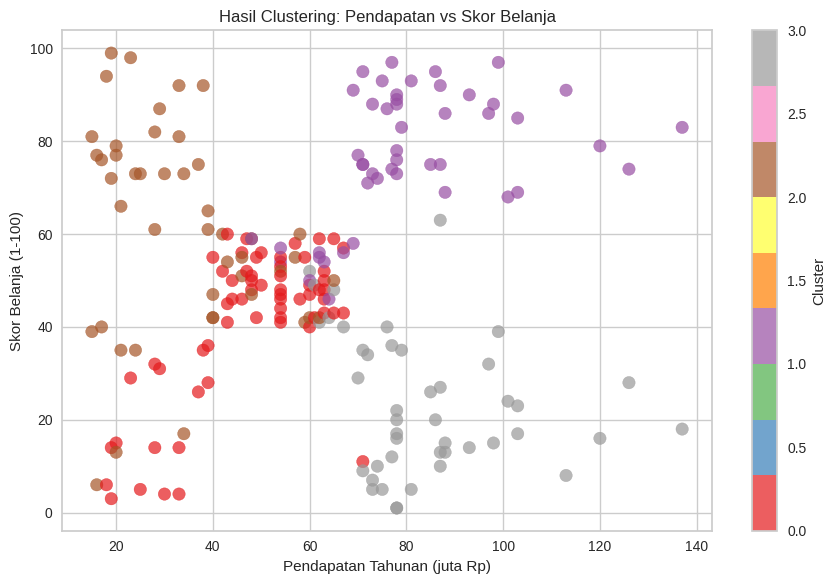

In [ ]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    df['Pendapatan Tahunan (juta Rp)'],
    df['Skor Belanja (1-100)'],
    c=df['Cluster'],
    cmap='Set1',
    s=80,
    alpha=0.7
)

plt.colorbar(scatter, label='Cluster')
plt.title('Hasil Clustering: Pendapatan vs Skor Belanja')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja (1-100)')
plt.tight_layout()
plt.show()

*Radar chart per cluster:*

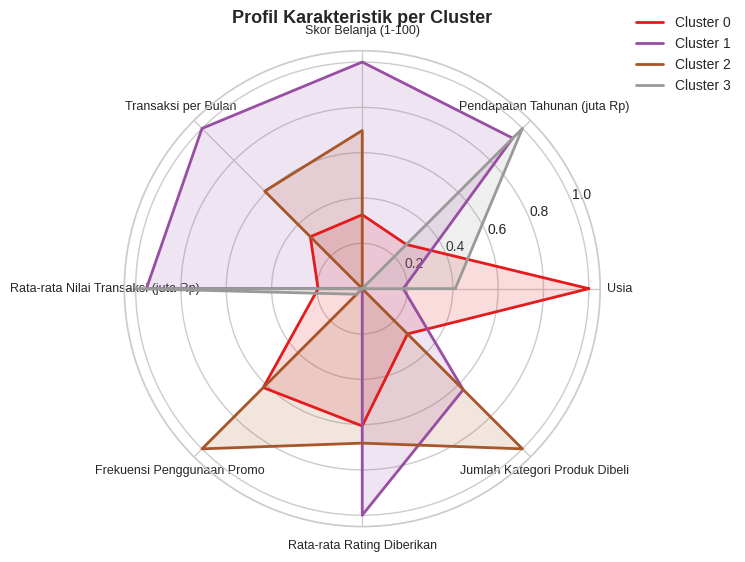

In [ ]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.cm as cm

# Normalisasi ringkasan untuk radar chart
ringkasan_norm = (ringkasan_cluster - ringkasan_cluster.min()) / \
                 (ringkasan_cluster.max() - ringkasan_cluster.min())

categories = kolom_analisis
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = cm.Set1(np.linspace(0, 1, K_OPTIMAL))

for i, row in ringkasan_norm.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f'Cluster {i}', color=colors[i])
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=9)
ax.set_title('Profil Karakteristik per Cluster', size=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

Kita membuat dua visualisasi untuk melihat kualitas cluster secara visual. Scatter plot
menampilkan posisi setiap pelanggan pada dua dimensi (Pendapatan vs Skor Belanja) dengan
warna berbeda per cluster — jika cluster terlihat mengelompok dan tidak terlalu tumpang tindih,
itu tanda model bekerja dengan baik. Radar chart menampilkan profil karakteristik setiap
cluster secara komprehensif dalam satu grafik, di mana setiap sumbu mewakili satu fitur.
Grafik ini sangat berguna untuk presentasi karena memperlihatkan perbedaan antar segmen
secara intuitif.

**13. Simpan Model & Hasil**

In [ ]:
import joblib

# Simpan model K-Means
joblib.dump(kmeans_final, 'model_kmeans.pkl')

# Simpan dataset dengan label cluster
df.to_csv('data_hasil_cluster.csv', index=False)

print("✅ Model dan hasil cluster berhasil disimpan!")

✅ Model dan hasil cluster berhasil disimpan!


In [ ]:
# Download
files.download('model_kmeans.pkl')
files.download('data_hasil_cluster.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model K-Means disimpan ke file .pkl menggunakan joblib. File ini menyimpan seluruh objek
model termasuk posisi centroid yang sudah dipelajari, sehingga model bisa digunakan kembali
tanpa perlu melatih ulang dari awal. Dataset dengan kolom Cluster juga disimpan sebagai file
CSV baru untuk dibagikan ke anggota kelompok yang mengerjakan tahap berikutnya.

**14.Evaluasi Metrik Utama**


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sil = silhouette_score(df_scaled, df['Cluster'])
db  = davies_bouldin_score(df_scaled, df['Cluster'])
ch  = calinski_harabasz_score(df_scaled, df['Cluster'])

print("╔══════════════════════════════════════╗")
print("║        HASIL EVALUASI MODEL          ║")
print("╠══════════════════════════════════════╣")
print(f"║ Silhouette Score      : {sil:.4f}       ║")
print(f"║ Davies-Bouldin Index  : {db:.4f}       ║")
print(f"║ Calinski-Harabasz     : {ch:.2f}     ║")
print("╚══════════════════════════════════════╝")

╔══════════════════════════════════════╗
║        HASIL EVALUASI MODEL          ║
╠══════════════════════════════════════╣
║ Silhouette Score      : 0.1685       ║
║ Davies-Bouldin Index  : 1.7992       ║
║ Calinski-Harabasz     : 39.47     ║
╚══════════════════════════════════════╝


Kita menggunakan tiga metrik untuk menilai kualitas clustering dari sudut pandang berbeda.
Silhouette Score mengukur seberapa baik setiap data point cocok di clusternya sendiri,
nilainya antara -1 hingga 1 dan semakin tinggi semakin baik. Davies-Bouldin Index mengukur
rata-rata kemiripan antar cluster, nilainya semakin rendah semakin baik karena berarti
cluster-cluster saling terpisah dengan jelas. Calinski-Harabasz Score mengukur rasio dispersi
antar cluster vs dalam cluster, semakin tinggi nilainya semakin baik.

**15.Visualisasi Silhouette per Cluster**

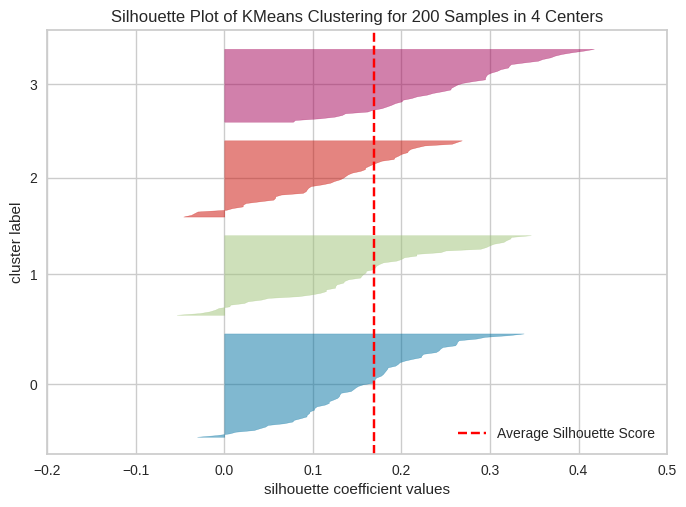

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 200 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer

model_eval = KMeans(n_clusters=K_OPTIMAL, random_state=42)

visualizer = SilhouetteVisualizer(model_eval, colors='yellowbrick')
visualizer.fit(df_scaled)
visualizer.show()

Selain nilai numerik, kita memvisualisasikan Silhouette Score secara grafis. Setiap bar pada
grafik mewakili satu data point dan panjangnya menunjukkan nilai Silhouette-nya. Garis merah
putus-putus adalah rata-rata keseluruhan. Bar yang melewati garis tersebut berarti data point
itu berada di cluster yang tepat. Cluster yang berkualitas baik memiliki bar yang seragam dan
sebagian besar melewati garis rata-rata.

**16.Analisis Mendalam Tiap Cluster**

In [ ]:
kolom_analisis = [
    'Usia', 'Pendapatan Tahunan (juta Rp)', 'Skor Belanja (1-100)',
    'Transaksi per Bulan', 'Rata-rata Nilai Transaksi (juta Rp)',
    'Frekuensi Penggunaan Promo', 'Rata-rata Rating Diberikan',
    'Jumlah Kategori Produk Dibeli'
]

print("=== PROFIL TIAP CLUSTER ===\n")
for i in range(K_OPTIMAL):
    data_cluster = df[df['Cluster'] == i]
    print(f"── Cluster {i} ({len(data_cluster)} pelanggan) ──")
    print(f"  Usia rata-rata         : {data_cluster['Usia'].mean():.1f} tahun")
    print(f"  Pendapatan rata-rata   : {data_cluster['Pendapatan Tahunan (juta Rp)'].mean():.1f} juta")
    print(f"  Skor Belanja rata-rata : {data_cluster['Skor Belanja (1-100)'].mean():.1f}")
    print(f"  Transaksi/bulan        : {data_cluster['Transaksi per Bulan'].mean():.1f}x")
    print(f"  Nilai transaksi rata2  : {data_cluster['Rata-rata Nilai Transaksi (juta Rp)'].mean():.1f} juta")
    print(f"  Frek. pakai promo      : {data_cluster['Frekuensi Penggunaan Promo'].mean():.1f}x")
    print(f"  Rating rata-rata       : {data_cluster['Rata-rata Rating Diberikan'].mean():.1f}")
    print(f"  Jenis Kelamin terbanyak: {df[df['Cluster'] == i]['Jenis Kelamin'].mode()[0]}")
    print(f"  Pembayaran favorit     : {df[df['Cluster'] == i]['Metode Pembayaran Favorit'].mode()[0]}")
    print()

=== PROFIL TIAP CLUSTER ===

── Cluster 0 (62 pelanggan) ──
  Usia rata-rata         : 54.2 tahun
  Pendapatan rata-rata   : 47.7 juta
  Skor Belanja rata-rata : 40.8
  Transaksi/bulan        : 2.2x
  Nilai transaksi rata2  : 1.9 juta
  Frek. pakai promo      : 2.6x
  Rating rata-rata       : 3.6
  Jenis Kelamin terbanyak: Perempuan
  Pembayaran favorit     : Bayar di Tempat

── Cluster 1 (48 pelanggan) ──
  Usia rata-rata         : 31.6 tahun
  Pendapatan rata-rata   : 81.1 juta
  Skor Belanja rata-rata : 76.8
  Transaksi/bulan        : 4.1x
  Nilai transaksi rata2  : 3.3 juta
  Frek. pakai promo      : 0.9x
  Rating rata-rata       : 3.8
  Jenis Kelamin terbanyak: Perempuan
  Pembayaran favorit     : Kartu Kredit

── Cluster 2 (46 pelanggan) ──
  Usia rata-rata         : 26.6 tahun
  Pendapatan rata-rata   : 33.9 juta
  Skor Belanja rata-rata : 60.7
  Transaksi/bulan        : 3.0x
  Nilai transaksi rata2  : 1.5 juta
  Frek. pakai promo      : 3.7x
  Rating rata-rata       : 3.6
  Jen

Cell ini mencetak ringkasan karakteristik setiap cluster secara detail menggunakan perulangan
for yang memfilter data per cluster satu per satu. Baca output cell ini dengan cermat karena
informasi di sini adalah dasar untuk menentukan nama segmen. Perhatikan kombinasi nilainya:
apakah pendapatannya tinggi atau rendah? Apakah sering bertransaksi? Apakah aktif menggunakan
promo? Jawaban dari kombinasi pertanyaan ini akan membentuk nama segmen yang tepat.

**17. Beri Nama Segmen**

In [ ]:
nama_cluster = {
    0: 'Pelanggan Senior Hemat',
    1: 'Pelanggan Premium Loyal',
    2: 'Pelanggan Muda Promo Hunter',
    3: 'Pelanggan Kaya Pasif'
}

df['Segmen'] = df['Cluster'].map(nama_cluster)

print("=== Distribusi Segmen ===")
print(df['Segmen'].value_counts())

=== Distribusi Segmen ===
Segmen
Pelanggan Senior Hemat         62
Pelanggan Premium Loyal        48
Pelanggan Muda Promo Hunter    46
Pelanggan Kaya Pasif           44
Name: count, dtype: int64


Setelah memahami profil tiap cluster, kita memberikan nama yang deskriptif dan bermakna secara
bisnis untuk setiap kelompok. Nama yang baik harus mencerminkan karakteristik dominan cluster
sehingga mudah dipahami oleh siapapun, termasuk yang tidak berlatar belakang teknis. Perhatikan
bahwa nama-nama di dalam kode hanyalah contoh — kamu wajib menggantinya berdasarkan hasil
analisis Cell 16 milikmu sendiri.

**Cell 18 — Visualisasi Evaluasi**

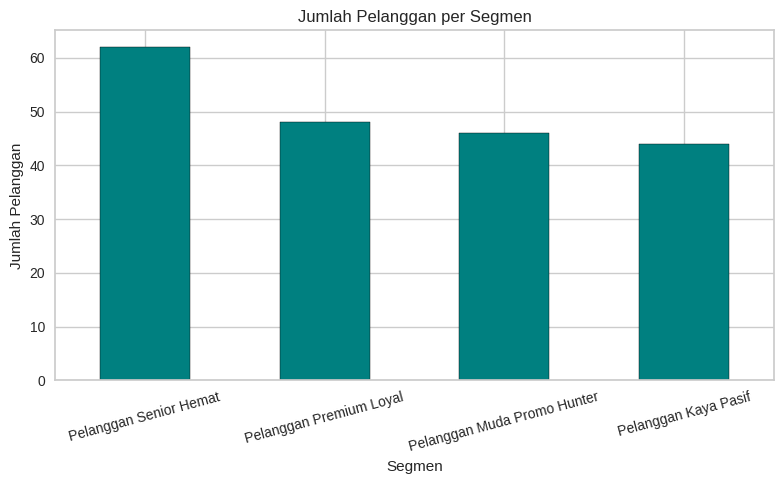

In [ ]:
plt.figure(figsize=(8, 5))
df['Segmen'].value_counts().plot(kind='bar', color='teal', edgecolor='black')
plt.title('Jumlah Pelanggan per Segmen')
plt.xlabel('Segmen')
plt.ylabel('Jumlah Pelanggan')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1614/585622539.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Segmen', y='Pendapatan Tahunan (juta Rp)',
/tmp/ipykernel_1614/585622539.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Segmen', y='Skor Belanja (1-100)',


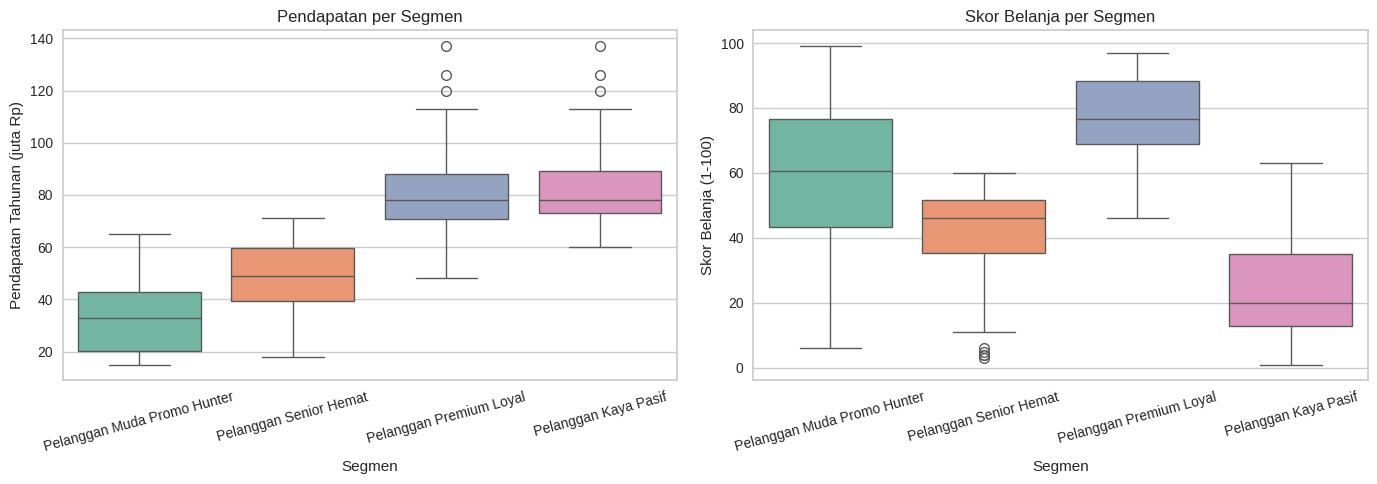

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Segmen', y='Pendapatan Tahunan (juta Rp)',
            palette='Set2', ax=axes[0])
axes[0].set_title('Pendapatan per Segmen')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df, x='Segmen', y='Skor Belanja (1-100)',
            palette='Set2', ax=axes[1])
axes[1].set_title('Skor Belanja per Segmen')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

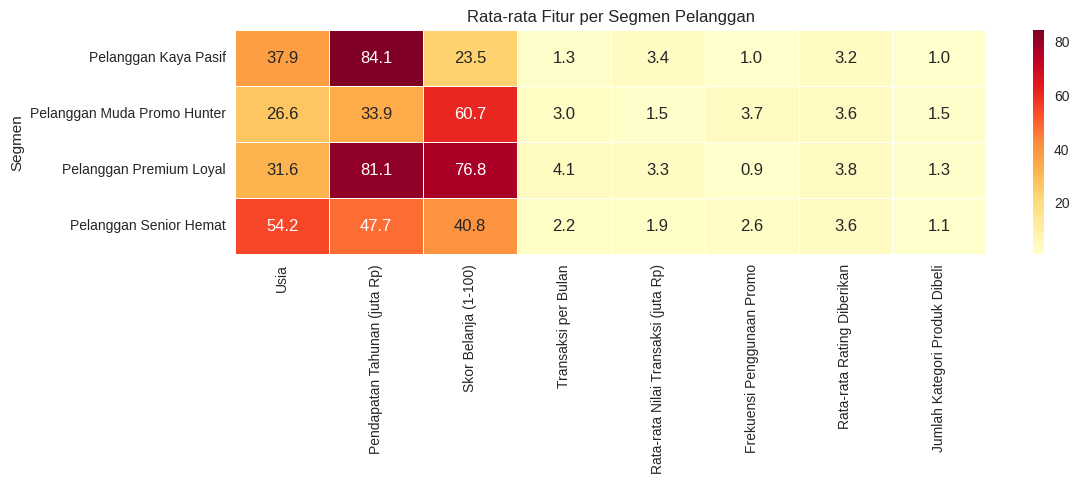

In [ ]:
heatmap_data = df.groupby('Segmen')[kolom_analisis].mean().round(1)

plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt='.1f', linewidths=0.5)
plt.title('Rata-rata Fitur per Segmen Pelanggan')
plt.tight_layout()
plt.show()

Kita membuat tiga visualisasi untuk memperkuat pemahaman tentang perbedaan antar segmen.
Bar chart menampilkan jumlah pelanggan di setiap segmen — distribusi yang relatif merata
adalah tanda yang baik. Boxplot menampilkan distribusi nilai pendapatan dan skor belanja per
segmen, lebih informatif dibanding rata-rata karena juga menampilkan median dan sebaran data.
Heatmap merangkum rata-rata semua fitur untuk semua segmen dalam satu tampilan sehingga
pola perbedaan antar segmen langsung terlihat dari perbedaan warnanya.

**19. Simpan Hasil Evaluasi**

In [ ]:
df.to_csv('data_hasil_evaluasi.csv', index=False)
heatmap_data.to_csv('ringkasan_segmen.csv')

print("✅ Hasil evaluasi berhasil disimpan!")
files.download('data_hasil_evaluasi.csv')
files.download('ringkasan_segmen.csv')

✅ Hasil evaluasi berhasil disimpan!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Kita menyimpan dua file output. data_hasil_evaluasi.csv adalah dataset lengkap yang kini
memiliki kolom tambahan Cluster dan Segmen, dan inilah output utama dari keseluruhan proyek.
ringkasan_segmen.csv berisi tabel rata-rata setiap fitur per segmen yang berguna sebagai
ringkasan eksekutif untuk bahan presentasi atau laporan.

 20. Tuning dengan GridSearch Manual

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Parameter yang akan dicoba
param_grid = {
    'n_clusters' : [3, 4, 5],
    'init'       : ['k-means++', 'random'],
    'max_iter'   : [100, 300, 500],
    'n_init'     : [10, 20]
}

hasil_tuning = []

for k in param_grid['n_clusters']:
    for init in param_grid['init']:
        for max_iter in param_grid['max_iter']:
            for n_init in param_grid['n_init']:
                model = KMeans(
                    n_clusters=k,
                    init=init,
                    max_iter=max_iter,
                    n_init=n_init,
                    random_state=42
                )
                labels = model.fit_predict(df_scaled)
                sil   = silhouette_score(df_scaled, labels)
                db    = davies_bouldin_score(df_scaled, labels)
                inertia = model.inertia_

                hasil_tuning.append({
                    'n_clusters' : k,
                    'init'       : init,
                    'max_iter'   : max_iter,
                    'n_init'     : n_init,
                    'silhouette' : round(sil, 4),
                    'davies_bouldin' : round(db, 4),
                    'inertia'    : round(inertia, 2)
                })

df_tuning = pd.DataFrame(hasil_tuning)
print(f"✅ Total kombinasi yang dicoba: {len(df_tuning)}")
df_tuning.head(10)

✅ Total kombinasi yang dicoba: 36


,n_clusters,init,max_iter,n_init,silhouette,davies_bouldin,inertia
0,3,k-means++,100,10,0.1660,1.6807,1395.80
1,3,k-means++,100,20,0.1660,1.6807,1395.80
2,3,k-means++,300,10,0.1660,1.6807,1395.80
3,3,k-means++,300,20,0.1660,1.6807,1395.80
4,3,k-means++,500,10,0.1660,1.6807,1395.80
5,3,k-means++,500,20,0.1660,1.6807,1395.80
6,3,random,100,10,0.1658,1.7271,1396.68
7,3,random,100,20,0.1687,1.6615,1396.55
8,3,random,300,10,0.1658,1.7271,1396.68
9,3,random,300,20,0.1687,1.6615,1396.55


Scikit-learn tidak menyediakan GridSearchCV untuk clustering karena tidak ada label target.
Maka kita membuat GridSearch sendiri dengan mendefinisikan semua nilai parameter yang ingin
dicoba, lalu menggunakan empat perulangan for bersarang untuk mencoba setiap kombinasinya.
Parameter yang kita tuning adalah n_clusters (jumlah cluster), init (metode inisialisasi
centroid), max_iter (batas iterasi konvergensi), dan n_init (berapa kali model diulang dengan
posisi awal berbeda). Untuk setiap kombinasi, kita melatih model dan menyimpan nilai
Silhouette Score serta Davies-Bouldin Index ke dalam sebuah list.

21. Temukan Kombinasi Terbaik

In [ ]:
# Terbaik berdasarkan Silhouette Score tertinggi
terbaik_sil = df_tuning.loc[df_tuning['silhouette'].idxmax()]

# Terbaik berdasarkan Davies-Bouldin terendah
terbaik_db = df_tuning.loc[df_tuning['davies_bouldin'].idxmin()]

print("╔══════════════════════════════════════════════╗")
print("║      PARAMETER TERBAIK — SILHOUETTE SCORE     ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  n_clusters  : {terbaik_sil['n_clusters']:<30}║")
print(f"║  init        : {terbaik_sil['init']:<30}║")
print(f"║  max_iter    : {terbaik_sil['max_iter']:<30}║")
print(f"║  n_init      : {terbaik_sil['n_init']:<30}║")
print(f"║  Silhouette  : {terbaik_sil['silhouette']:<30}║")
print(f"║  Davies-Bouldin : {terbaik_sil['davies_bouldin']:<27}║")
print("╚══════════════════════════════════════════════╝")

print()

print("╔══════════════════════════════════════════════╗")
print("║   PARAMETER TERBAIK — DAVIES-BOULDIN INDEX   ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  n_clusters  : {terbaik_db['n_clusters']:<30}║")
print(f"║  init        : {terbaik_db['init']:<30}║")
print(f"║  max_iter    : {terbaik_db['max_iter']:<30}║")
print(f"║  n_init      : {terbaik_db['n_init']:<30}║")
print(f"║  Silhouette  : {terbaik_db['silhouette']:<30}║")
print(f"║  Davies-Bouldin : {terbaik_db['davies_bouldin']:<27}║")
print("╚══════════════════════════════════════════════╝")

╔══════════════════════════════════════════════╗
║      PARAMETER TERBAIK — SILHOUETTE SCORE     ║
╠══════════════════════════════════════════════╣
║  n_clusters  : 5                             ║
║  init        : random                        ║
║  max_iter    : 100                           ║
║  n_init      : 10                            ║
║  Silhouette  : 0.1725                        ║
║  Davies-Bouldin : 1.6618                     ║
╚══════════════════════════════════════════════╝

╔══════════════════════════════════════════════╗
║   PARAMETER TERBAIK — DAVIES-BOULDIN INDEX   ║
╠══════════════════════════════════════════════╣
║  n_clusters  : 3                             ║
║  init        : random                        ║
║  max_iter    : 100                           ║
║  n_init      : 20                            ║
║  Silhouette  : 0.1687                        ║
║  Davies-Bouldin : 1.6615                     ║
╚══════════════════════════════════════════════╝


Setelah semua kombinasi dicoba, kita menggunakan idxmax() untuk menemukan baris dengan
Silhouette Score tertinggi dan idxmin() untuk menemukan baris dengan Davies-Bouldin terendah.
Jika keduanya menunjuk ke kombinasi yang sama, kita semakin yakin itulah parameter terbaik.
Jika berbeda, prioritaskan Silhouette Score karena lebih umum digunakan sebagai standar evaluasi
clustering, namun tetap pertimbangkan apakah n_clusters-nya konsisten dengan hasil Elbow Method.

22. Visualisasi Hasil Tuning

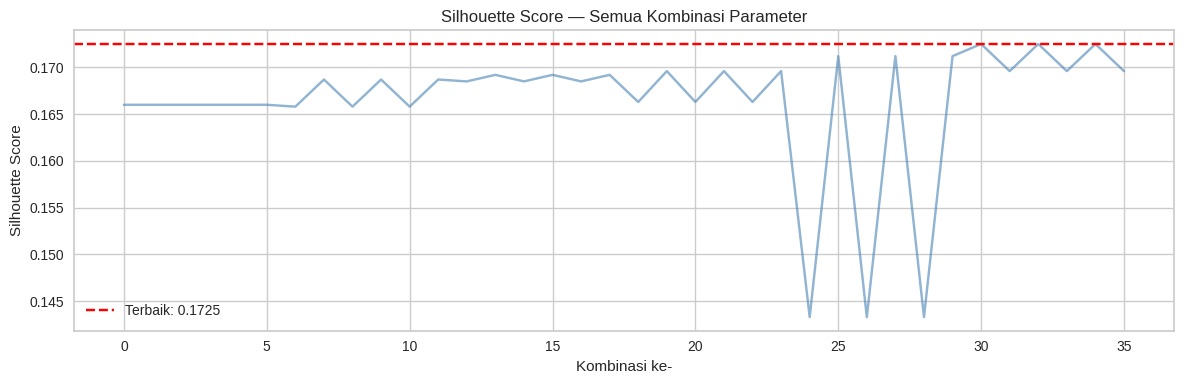

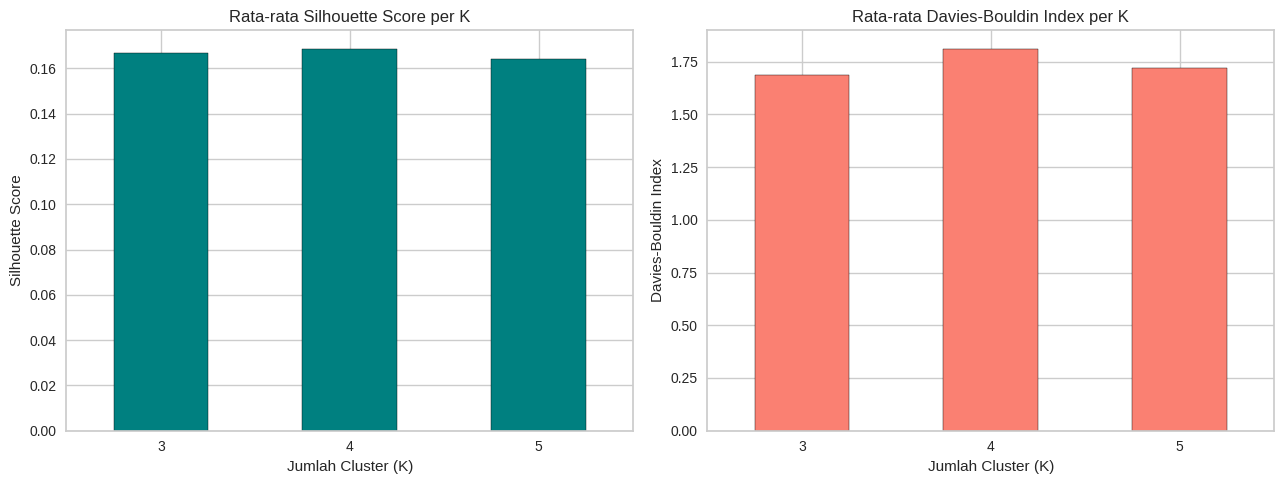

In [ ]:
import matplotlib.pyplot as plt

# Grafik 1: Semua Kombinasi
plt.figure(figsize=(12, 4))
plt.plot(range(len(df_tuning)), df_tuning['silhouette'], color='steelblue', alpha=0.6)
plt.axhline(y=terbaik_sil['silhouette'], color='red', linestyle='--',
            label=f"Terbaik: {terbaik_sil['silhouette']}")
plt.title('Silhouette Score — Semua Kombinasi Parameter')
plt.xlabel('Kombinasi ke-')
plt.ylabel('Silhouette Score')
plt.legend()
plt.tight_layout()
plt.show()

# Grafik 2: Perbandingan antar Nilai K
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Silhouette per K
df_tuning.groupby('n_clusters')['silhouette'].mean().plot(
    kind='bar', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Rata-rata Silhouette Score per K')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Silhouette Score')
axes[0].tick_params(axis='x', rotation=0)

# Davies-Bouldin per K
df_tuning.groupby('n_clusters')['davies_bouldin'].mean().plot(
    kind='bar', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Rata-rata Davies-Bouldin Index per K')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Kita membuat dua visualisasi untuk memahami hasil tuning secara intuitif. Grafik garis
menampilkan nilai Silhouette Score dari semua kombinasi yang dicoba, dengan garis merah
menandai nilai terbaik. Bar chart membandingkan rata-rata Silhouette Score dan Davies-Bouldin
per nilai K, sehingga kita bisa melihat apakah perbedaan performa lebih dipengaruhi oleh
jumlah cluster atau oleh parameter lainnya.

23. Training Model Final dengan Parameter Terbaik

In [ ]:
# Gunakan parameter terbaik dari hasil tuning
model_final = KMeans(
    n_clusters = int(terbaik_sil['n_clusters']),
    init        = terbaik_sil['init'],
    max_iter   = int(terbaik_sil['max_iter']),
    n_init     = int(terbaik_sil['n_init']),
    random_state = 42
)

df['Cluster Final'] = model_final.fit_predict(df_scaled)

# Evaluasi model final
sil_final = silhouette_score(df_scaled, df['Cluster Final'])
db_final  = davies_bouldin_score(df_scaled, df['Cluster Final'])

print("╔══════════════════════════════════════╗")
print("║      EVALUASI MODEL FINAL            ║")
print("╠══════════════════════════════════════╣")
print(f"║  Silhouette Score    : {sil_final:.4f}        ║")
print(f"║  Davies-Bouldin      : {db_final:.4f}        ║")
print("╚══════════════════════════════════════╝")

print()
print("=== Distribusi Cluster Final ===")
print(df['Cluster Final'].value_counts().sort_index())

╔══════════════════════════════════════╗
║      EVALUASI MODEL FINAL            ║
╠══════════════════════════════════════╣
║  Silhouette Score    : 0.1725        ║
║  Davies-Bouldin      : 1.6618        ║
╚══════════════════════════════════════╝

=== Distribusi Cluster Final ===
Cluster Final
0    22
1    62
2    44
3    49
4    23
Name: count, dtype: int64


Setelah menemukan parameter terbaik, kita melatih ulang model K-Means menggunakan parameter
tersebut secara eksplisit. Hasilnya disimpan sebagai kolom Cluster Final yang terpisah dari
kolom Cluster model awal, agar keduanya bisa dibandingkan secara langsung pada cell berikutnya.

24. Bandingkan Model Sebelum vs Sesudah Tuning

            Metrik  Sebelum Tuning  Sesudah Tuning
Silhouette Score ↑          0.1685          0.1725
  Davies-Bouldin ↓          1.7992          1.6618


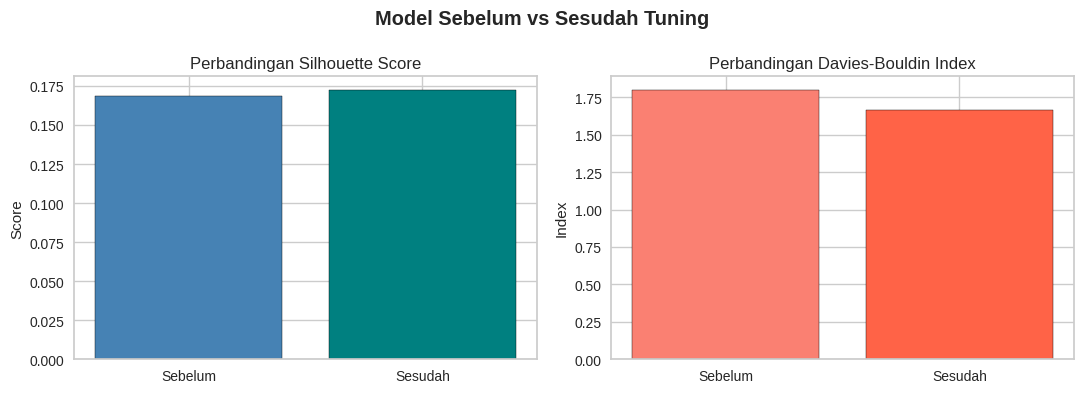

In [ ]:
sil_sebelum = silhouette_score(df_scaled, df['Cluster'])
db_sebelum  = davies_bouldin_score(df_scaled, df['Cluster'])

perbandingan = pd.DataFrame({
    'Metrik'         : ['Silhouette Score ↑', 'Davies-Bouldin ↓'],
    'Sebelum Tuning' : [round(sil_sebelum, 4), round(db_sebelum, 4)],
    'Sesudah Tuning' : [round(sil_final, 4),   round(db_final, 4)]
})

print(perbandingan.to_string(index=False))

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['Sebelum', 'Sesudah'],
            [sil_sebelum, sil_final],
            color=['steelblue', 'teal'], edgecolor='black')
axes[0].set_title('Perbandingan Silhouette Score')
axes[0].set_ylabel('Score')

axes[1].bar(['Sebelum', 'Sesudah'],
            [db_sebelum, db_final],
            color=['salmon', 'tomato'], edgecolor='black')
axes[1].set_title('Perbandingan Davies-Bouldin Index')
axes[1].set_ylabel('Index')

plt.suptitle('Model Sebelum vs Sesudah Tuning', fontweight='bold')
plt.tight_layout()
plt.show()

Kita membandingkan performa model sebelum dan sesudah tuning secara berdampingan menggunakan
tabel dan bar chart. Jika model sesudah tuning menunjukkan Silhouette Score lebih tinggi dan
Davies-Bouldin lebih rendah, maka optimalisasi berhasil. Jika perbedaannya sangat kecil, itu
pun informasi yang valid — artinya parameter default sudah cukup baik untuk dataset ini.

25. Simpan Semua Hasil

In [ ]:
import joblib
from google.colab import files

# Simpan model final
joblib.dump(model_final, 'model_kmeans_final.pkl')

# Simpan hasil tuning lengkap
df_tuning.to_csv('hasil_tuning.csv', index=False)

# Simpan dataset final
df.to_csv('data_final.csv', index=False)

print("✅ Semua hasil berhasil disimpan!")

# Mengunduh file otomatis ke komputer kamu
files.download('model_kmeans_final.pkl')
files.download('hasil_tuning.csv')
files.download('data_final.csv'

✅ Semua hasil berhasil disimpan!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Di cell terakhir ini kita menyimpan tiga file output. model_kmeans_final.pkl adalah model yang
sudah dioptimasi dan siap digunakan untuk memprediksi cluster pelanggan baru. hasil_tuning.csv
berisi tabel semua kombinasi parameter beserta nilai metriknya, berguna sebagai dokumentasi
proses optimalisasi. data_final.csv adalah dataset akhir yang merangkum seluruh hasil proyek
dari awal hingga akhir.